# Building an MNIST CNN Model with PyTorch

## Introduction to the Lecture

**Purpose of this Lecture:**
This lecture aims to introduce you to the fundamental concepts of PyTorch, a powerful open-source machine learning library. We'lldo this by working through a practical example: building an image classification model. By the end of this session, you'll have a foundational understanding of how to define, train, and test a simple neural network using PyTorch.

**The MNIST Example: What Are We Doing?**
We will be working with the **MNIST dataset** (pronounced "em-nist"). This is a famous dataset in the machine learning world, consisting of 70,000 grayscale images of handwritten digits, from 0 to 9 (60,000 for training and 10,000 for testing). Each image is small, 28x28 pixels.
Our goal is to build a **Convolutional Neural Network (CNN)** that can look at one of these handwritten digit images and correctly predict which digit it is (0, 1, 2, ..., 9).

**Why This Example?**
*   **MNIST - A Classic Starting Point:** MNIST is often called the "hello world" of image classification. Its simplicity and small size make it an ideal dataset for beginners to learn the basics without getting bogged down by large, complex data.
*   **CNNs - Fundamental for Images:** Convolutional Neural Networks are a cornerstone of modern computer vision. Understanding their basic structure is crucial for anyone interested in working with image data. This example provides a gentle introduction.
*   **PyTorch - Flexible and Pythonic:** PyTorch is widely used in both research and industry. It's known for its Python-friendly interface, dynamic computation graphs (which offer flexibility), and strong GPU acceleration. Learning PyTorch is a valuable skill.

**Learning Outcomes:**
By completing this exercise, you will learn to:
1.  Load and prepare image datasets (like MNIST) specifically for use in PyTorch.
2.  Understand and use **Tensors**, the core data structure in PyTorch.
3.  Define a simple Convolutional Neural Network (CNN) architecture using PyTorch's `nn.Module`.
4.  Understand the roles of an **optimizer** (like Adam) and a **loss function** (like Cross-Entropy Loss) in training a neural network.
5.  Implement the basic training loop:
    *   **Forward Pass:** Getting predictions from the model.
    *   **Loss Calculation:** Measuring how good/bad the predictions are.
    *   **Backward Pass (Backpropagation):** Calculating gradients to understand how to improve the model.
    *   **Optimizer Step:** Updating the model's parameters (weights) to make it better.
6.  Evaluate your model's performance on unseen test data to see how well it has learned.

**Brief Explanation of Key Concepts (for Absolute Beginners):**
Don't worry if these terms are new; we'll see them in action!
*   **Neural Network (NN):** Imagine a computer system that learns from examples, much like a human brain. It's made of interconnected units called "neurons" that work together to process information and make decisions or predictions.
*   **Convolutional Neural Network (CNN):** A special type of neural network that's really good at understanding images. It uses "convolutional" layers that act like sets of learnable filters, sliding across images to detect patterns like edges, textures, and shapes.
*   **Tensor:** In PyTorch (and other deep learning frameworks), a tensor is the main way we store and manipulate data. Think of it as a multi-dimensional array or grid of numbers. A 1D tensor is a vector, a 2D tensor is a matrix, and you can have 3D, 4D, or even higher-dimensional tensors (e.g., a batch of color images might be a 4D tensor: batch_size x height x width x color_channels).
*   **Training:** This is the process of "teaching" the neural network. We show it lots of example images and their correct labels (e.g., this image is a "7"). The network makes a prediction, we see how wrong it is, and then we slightly adjust its internal settings (called "weights") to make it more accurate next time.
*   **Epoch:** One complete round of showing the *entire* training dataset to the neural network. We usually train for multiple epochs.
*   **Batch:** Because training datasets can be very large, we often break them into smaller chunks called batches. The model processes one batch at a time within an epoch.
*   **Loss Function (or Criterion):** A mathematical function that measures how "wrong" the model's predictions are compared to the actual correct answers (labels). A high loss means the model is doing poorly; a low loss means it's doing well. The main goal of training is to minimize this loss.
*   **Optimizer:** An algorithm that helps the neural network adjust its internal weights to reduce the loss. It uses the information from the loss function to decide how to change the weights to make better predictions. Adam, SGD (Stochastic Gradient Descent), and RMSprop are common optimizers.
*   **Activation Function (e.g., ReLU):** A function applied to the output of neurons within the network. They introduce non-linearity, which is crucial for the network to learn complex relationships in the data. ReLU (Rectified Linear Unit) is a very common one; it basically outputs the input if it's positive, and zero otherwise.
*   **Softmax:** Often used as the last activation function in a classification model. It takes a vector of raw scores (logits) from the network and converts them into a vector of probabilities, where each probability represents how likely the input image is to belong to a particular class (e.g., 70% chance it's a '2', 10% it's a '7', etc.). All probabilities sum up to 1.
---

## 1. Load Libraries

This first code block is dedicated to importing all the necessary Python libraries and modules that we'll use throughout this notebook. Libraries are collections of pre-written code that provide useful functions and tools, so we don't have to write everything from scratch.

Here's a brief overview of the key libraries we're importing:

*   **`torch`**: This is the main PyTorch library. It provides the core functionalities like tensor operations (the fundamental data structures for PyTorch) and automatic differentiation (which is key for training neural networks).
*   **`torch.nn`**: This submodule of PyTorch contains the building blocks for constructing neural networks, such_as layers (convolutional, linear, etc.), activation functions, and loss functions. `nn` stands for Neural Network.
*   **`torch.nn.functional` (often imported as `F`)**: This module contains functions that are used in building neural networks, like activation functions (e.g., ReLU) and pooling operations. It's often used for functions that don't have learnable parameters.
*   **`torchvision`**: This library is part of the PyTorch ecosystem and provides access to popular datasets, pre-trained model architectures, and common image transformations for computer vision tasks.
*   **`torchvision.transforms`**: A submodule of `torchvision` that provides tools for pre-processing image data, such as converting images to tensors, normalizing them, or applying data augmentation techniques.
*   **`torchvision.datasets`**: This submodule makes it easy to download and use standard datasets like MNIST, CIFAR10, ImageNet, etc.
*   **`pandas` (as `pd`)**: A powerful library for data manipulation and analysis, particularly useful for working with tabular data (though not heavily used in this specific image-focused notebook).
*   **`numpy` (as `np`)**: A fundamental package for numerical computation in Python. PyTorch tensors can be easily converted to and from NumPy arrays.
*   **`torch.utils.data.Dataset` and `torch.utils.data.DataLoader`**: These are PyTorch utilities that help in creating custom datasets and loading data efficiently in batches during model training and evaluation.
*   **`sklearn.metrics.recall_score`**: A function from scikit-learn, a comprehensive machine learning library, to calculate the recall score. While not directly used in the main training loop here, it's imported and could be used for more detailed evaluation.
*   **`matplotlib.pyplot` (as `plt`)**: A widely used plotting library in Python. We'll use it to display images from our dataset.
*   **`joblib`**: A library for lightweight pipelining in Python. It can be useful for saving and loading Python objects, including trained models or data.
*   **`tqdm`**: A library that provides a simple and effective way to add progress bars to loops, which is very helpful for monitoring the progress of time-consuming tasks like training neural networks.
*   **`os`**: A standard Python library for interacting with the operating system, for example, to manage files and directories.
*   **`random`**: A standard Python library for generating random numbers, which can be useful for various tasks like shuffling data or initializing parameters.

The lines `%reload_ext autoreload`, `%autoreload 2`, and `%matplotlib inline` are "magic commands" often used in Jupyter Notebooks:
*   `%reload_ext autoreload` and `%autoreload 2`: These commands automatically reload modules before executing code. This is useful if you're editing external Python scripts and want the changes to be reflected in the notebook without restarting the kernel.
*   `%matplotlib inline`: This command ensures that plots generated by `matplotlib` are displayed directly within the notebook interface.
---

## 1. Load Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import joblib
from tqdm import tqdm
import os
import random

%reload_ext autoreload
%autoreload 2
%matplotlib inline

## 2. Read / Import Data & Initial Setup

In this section, we'll set up some basic parameters and then download and prepare our dataset.

*   **`BATCH_SIZE = 32` (or 64, 128):**
    *   When training neural networks, we usually don't feed the entire dataset to the model at once. Instead, we divide it into smaller, manageable chunks called **batches**.
    *   `BATCH_SIZE` defines how many samples (images, in our case) are included in each batch.
    *   **Why use batches?**
        *   **Memory Efficiency:** Processing the entire dataset at once might require more memory (RAM or GPU VRAM) than available. Batches make it feasible to train on large datasets.
        *   **Faster Training (per update):** The model's weights are updated after processing each batch. Smaller batches mean more frequent updates, which can sometimes lead to faster convergence.
        *   **Stable Gradient Estimation:** While very small batches can lead to noisy gradient estimates, moderately sized batches provide a good balance, offering a more stable estimate of the gradient across the dataset compared to processing one sample at a time (stochastic gradient descent).
    *   The choice of batch size (e.g., 32, 64, 128) is a hyperparameter that can affect training speed and model performance. There's no single "best" size; it often depends on the dataset, model, and available hardware.

*   **`transform = transforms.Compose([...])`**:
    *   PyTorch's `torchvision.transforms` module provides tools for common image transformations. `transforms.Compose` allows us to chain multiple transformations together.
    *   **`transforms.ToTensor()`**: This is a crucial transformation. It converts images (which might be in formats like PIL Image or NumPy arrays) into PyTorch **Tensors**.
        *   For PIL Images, it also changes the pixel value range from `[0, 255]` (typical for images) to `[0.0, 1.0]` (a floating-point range suitable for neural networks) by dividing each pixel value by 255.
        *   It rearranges the dimensions of the image tensor from HWC (Height, Width, Channel) to CHW (Channel, Height, Width), which is the format PyTorch's convolutional layers expect. Since MNIST images are grayscale, the channel will be 1.

*   **`trainset = torchvision.datasets.MNIST(...)`** and **`testset = torchvision.datasets.MNIST(...)`**:
    *   These lines download the MNIST dataset using `torchvision.datasets.MNIST`. PyTorch makes it very convenient to access many standard datasets.
    *   **`root='./data'`**: Specifies the directory where the MNIST data will be downloaded or, if already downloaded, where it's stored.
    *   **`train=True`**: This flag indicates that we want to load the **training** portion of the MNIST dataset. This is the data the model will learn from.
    *   **`train=False`**: This flag indicates that we want to load the **testing** (or evaluation) portion of the MNIST dataset. This data is kept separate and is used to evaluate how well our trained model generalizes to new, unseen images. It's crucial not to train the model on the test data.
    *   **`download=True`**: If the MNIST dataset is not found in the `root` directory, this option allows PyTorch to download it automatically.
    *   **`transform=transform`**: This applies the transformations we defined earlier (in our case, `transforms.ToTensor()`) to each image as it's loaded from the dataset. This means each image will be converted into a PyTorch tensor with pixel values between 0.0 and 1.0.

The output of this cell (the download progress bars) shows that PyTorch is fetching the dataset files. These typically include files for training images, training labels, test images, and test labels.
---

## 2. Read / Import Data

In [ ]:
BATCH_SIZE = 32 # or 64, 128

## transform the data into 'tensors' using the 'transforms' module
transform = transforms.Compose(
    [transforms.ToTensor()])

## download training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
## download testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.72MB/s]


## 3. Load Data on DataLoader

Now that we have our datasets (`trainset` and `testset`), we need an efficient way to load the data in batches during the training and evaluation phases. This is where PyTorch's `DataLoader` comes in.

*   **`torch.utils.data.DataLoader`**:
    *   This utility takes a `Dataset` object (like our `trainset` and `testset`) and provides an iterable over it. This means we can easily loop through our data.
    *   It handles batching, shuffling, and can even use multiple worker processes to load data in parallel (though we're keeping it simple here).

Let's look at the parameters used:

*   **`trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)`**:
    *   `trainset`: The training dataset we prepared earlier.
    *   `batch_size=BATCH_SIZE`: We use the `BATCH_SIZE` (which we set to 32) that we defined previously. This means the `trainloader` will provide 32 images (and their labels) at a time.
    *   `shuffle=True`: This is a very important parameter for the training data loader. Setting it to `True` means that the order of the data will be randomized at the beginning of each epoch.
        *   **Why shuffle?** Shuffling helps the model generalize better and prevents it from learning any unintended order present in the dataset. If the data isn't shuffled, the model might learn patterns related to the sequence of data, especially if similar samples are grouped together. It also helps ensure that batches are more representative of the overall data distribution.
    *   `num_workers=0`: This parameter determines how many subprocesses to use for data loading. `0` means the data will be loaded in the main process. For simple datasets like MNIST and on most personal machines, `0` is often fine. Increasing this can speed up data loading for larger datasets or more complex transformations by loading data in parallel, but can sometimes cause issues on Windows or in certain environments if not configured correctly.

*   **`testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)`**:
    *   `testset`: The test dataset.
    *   `batch_size=BATCH_SIZE`: We often use the same batch size for testing as for training, but it can be different. For evaluation, especially if memory is a concern, a larger batch size can sometimes speed things up as there are fewer iterations.
    *   `shuffle=False`: For the test (and validation) dataset, we **do not** shuffle the data. The order of evaluation doesn't impact the model's learning (as weights are not updated during testing), and keeping it consistent allows for reproducible evaluation metrics and easier comparison across different test runs or models.
    *   `num_workers=0`: Same reasoning as for the `trainloader`.

After this cell runs, `trainloader` and `testloader` are ready to be used in our training and testing loops to feed data to the model in an organized and efficient manner.
---

## 3. Load Data on DataLoader

In [ ]:
# Feed data in batches into deep-learning models
# num_workers=0 in Windows machine
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=0)

## 4. Explore the Data (EDA)

Before diving into model building, it's often a good idea to visually inspect your data. This is a part of Exploratory Data Analysis (EDA). It helps ensure that the data has loaded correctly and gives you a feel for what you're working with. In this section, we'll define a helper function to display images and then use it to look at a few examples from our training set.

*   **`def imshow(img):`**:
    *   This defines a Python function named `imshow` that takes an image tensor (`img`) as input.
    *   **`#img = img / 2 + 0.5 # unnormalize`**: This line is commented out. If the images were normalized to a range like `[-1, 1]` (e.g., by subtracting the mean and dividing by standard deviation), this line would be used to "unnormalize" them back to a displayable range (often `[0, 1]`) before showing them. Since `transforms.ToTensor()` already scales images to `[0, 1]`, this specific unnormalization isn't strictly needed here.
    *   **`npimg = img.numpy()`**: Converts the PyTorch tensor `img` into a NumPy array. `matplotlib`'s `imshow` function typically expects data in NumPy array format.
    *   **`plt.imshow(np.transpose(npimg, (1, 2, 0)))`**: This is the core line for displaying the image.
        *   `plt.imshow()`: The function from `matplotlib.pyplot` (imported as `plt`) used to display data as an image.
        *   `np.transpose(npimg, (1, 2, 0))`: This is an important step. PyTorch tensors for images are typically in the CHW format (Channel, Height, Width). However, `matplotlib` expects images in HWC format (Height, Width, Channel). `np.transpose(npimg, (1, 2, 0))` rearranges the dimensions of the NumPy array from `(Channel, Height, Width)` to `(Height, Width, Channel)`. For our grayscale MNIST images, the input might be `(1, 28, 28)`, and this would transpose it to `(28, 28, 1)`.

*   **Getting and Displaying Images:**
    *   **`dataiter = iter(trainloader)`**: Creates an iterator from our `trainloader`. An iterator is an object that allows us to loop through a sequence one item (in this case, one batch) at a time.
    *   **`images, labels = next(dataiter)`**: Retrieves the next batch (the first batch, in this instance) of images and their corresponding labels from the `trainloader`. `images` will be a tensor containing a batch of image data, and `labels` will be a tensor containing their labels.
    *   **`imshow(torchvision.utils.make_grid(images))`**:
        *   `torchvision.utils.make_grid(images)`: This utility function takes a batch of images (as a 4D tensor) and arranges them into a single grid image. This is very convenient for visualizing multiple images from a batch at once.
        *   The resulting grid image (which is a tensor) is then passed to our `imshow` function to be displayed.

The output of this cell will be a grid showing several of the MNIST handwritten digit images from the first batch of our training data. This helps confirm that our data loading and transformations are working as expected.
---

## 4. Explore the Data (EDA)

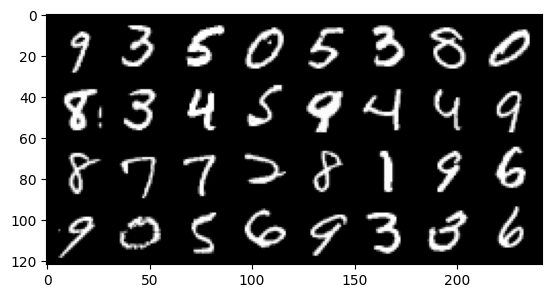

In [ ]:
## functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

## get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

## show images
imshow(torchvision.utils.make_grid(images))

### Checking Data Dimensions

After loading the data and visualizing some samples, it's good practice to explicitly check the dimensions (or "shape") of our data tensors. This helps us confirm that the data is structured as expected by our model and can prevent errors down the line.

*   **`for images, labels in trainloader:`**: We start a loop that iterates through the `trainloader`. Each iteration will give us one batch of `images` and their corresponding `labels`.
*   **`print("Image batch dimensions:", images.shape)`**:
    *   `images.shape`: This attribute of a PyTorch tensor returns a `torch.Size` object, which is like a tuple describing the size of each dimension of the tensor.
    *   For our MNIST data, we expect this to be something like `torch.Size([32, 1, 28, 28])`. Let's break this down:
        *   `32`: This is the `BATCH_SIZE`, meaning there are 32 images in this batch.
        *   `1`: This is the number of **color channels**. Since MNIST images are grayscale, there's only one channel. For RGB color images, this would typically be 3.
        *   `28`: This is the **height** of each image in pixels.
        *   `28`: This is the **width** of each image in pixels.
*   **`print("Image label dimensions:", labels.shape)`**:
    *   `labels.shape`: This gives us the dimensions of the labels tensor for the current batch.
    *   For our MNIST data, we expect this to be `torch.Size([32])`. This means there are 32 labels in this batch, one for each of the 32 images. Each label will be a number between 0 and 9.
*   **`break`**: After processing and printing the dimensions for the first batch, we use `break` to exit the loop. We only need to check the dimensions once to verify the structure.

The commented-out code cell that follows in the original notebook (`# Image batch dimensions: torch.Size([32, 1, 28, 28]) --> ...`) simply reiterates this interpretation. Understanding these dimensions is crucial for designing the input layer of our neural network correctly.
---

In [ ]:
## Check the dimensions of a batch:
for images, labels in trainloader:
    print("Image batch dimensions:", images.shape)
    print("Image label dimensions:", labels.shape)
    break

Image batch dimensions: torch.Size([32, 1, 28, 28])
Image label dimensions: torch.Size([32])


In [ ]:
# Image batch dimensions: torch.Size([32, 1, 28, 28]) -->
# 32: samples, 1 color channel, 28 x 28 (height x width)
# Image label dimensions: torch.Size([32])

## 5. Create a Model, Optimizer, and Criterion (Loss Function)

This section is pivotal as it's where we define the core components for our machine learning task:
1.  **The Neural Network Model:** This is the architecture that will learn to classify the digits.
2.  **The Optimizer:** The algorithm that will adjust our model's parameters (weights) to improve its performance.
3.  **The Criterion (Loss Function):** The function that will measure how well our model is performing by quantifying the difference between its predictions and the actual labels.

The next few cells will walk through defining each of these. The original notebook includes a commented code cell here that acts as a preamble to defining the model structure, particularly the convolutional layer. We'll cover these details more thoroughly in the explanation for the actual model class definition (`MyModel`) which follows.
---

## 5. Create a model, optimizer and criterion

# The model below consists of an __init__() portion where you include the layers and components of the neural network.
# In our model, we have a convolutional layer denoted by nn.Conv2d(...).
# We are dealing with an image dataset that is in grayscale so we only need one channel going in, so "in_channels=1".
# We hope to get a nice representation of this layer, so we use "out_channels=32".
# Kernel size is 3, and for the rest of parameters, we use the default values which you can find here.

### Defining Our Neural Network: `MyModel`

This code block defines the architecture of our Convolutional Neural Network (CNN). In PyTorch, custom models are created by defining a class that inherits from `nn.Module`. This base class provides a lot of underlying functionality for tracking parameters, moving the model between devices (CPU/GPU), and more.

A PyTorch model class typically has two main parts:
1.  **`__init__(self)` (The Constructor):** Here, you define all the layers that your network will use. These layers are stored as attributes of the class.
2.  **`forward(self, x)`:** This method defines the "forward pass" of the network – how input data `x` flows through the layers you defined in `__init__` to produce an output.

Let's break down our `MyModel`:

```python
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
```
*   **`class MyModel(nn.Module):`**: Declares our model class, inheriting from `torch.nn.Module`.
*   **`super(MyModel, self).__init__():`**: This line is crucial. It calls the constructor of the parent class (`nn.Module`), ensuring that all necessary initializations from `nn.Module` are performed.

```python
    # 28x28x1 => 26x26x32
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
```
*   **`self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)`**: This line defines our first (and only, in this simple model) convolutional layer.
    *   `nn.Conv2d`: This is the PyTorch module for a 2D convolutional layer, suitable for image data.
    *   `in_channels=1`: This specifies the number of channels in the input image. Since MNIST images are grayscale, they have 1 channel. If we were using color images (RGB), this would typically be 3.
    *   `out_channels=32`: This is the number of filters (also known as kernels or feature detectors) the convolutional layer will learn. Each filter learns to detect a specific pattern in the input. The number 32 here is a design choice; more filters can potentially capture more complex features but also increase the number of parameters in the model.
    *   `kernel_size=3`: This defines the dimensions of the filters (3x3 pixels). A 3x3 kernel will slide over the input image.
    *   **Output Size Calculation (`28x28x1 => 26x26x32`):**
        *   The input images are 28x28 (1 channel).
        *   A 3x3 kernel, when applied to a 28x28 image without padding, reduces the spatial dimensions. The output height/width can be calculated as: `(Input_Dim - Kernel_Size) / Stride + 1`.
        *   With default stride of 1 and no padding: `(28 - 3) / 1 + 1 = 25 + 1 = 26`.
        *   So, the output of this convolutional layer will have spatial dimensions of 26x26.
        *   Since we have `out_channels=32`, the output volume will be `26x26x32`.

```python
    self.d1 = nn.Linear(26 * 26 * 32, 128)
```
*   **`self.d1 = nn.Linear(26 * 26 * 32, 128)`**: This defines our first fully connected layer (also called a dense layer or linear layer).
    *   `nn.Linear`: The PyTorch module for a linear transformation (`y = Wx + b`).
    *   `in_features = 26 * 26 * 32`: This is the number of input features to this layer. It's calculated by "flattening" the 3D output volume of the `conv1` layer (`26x26x32 = 21632`). Convolutional layers typically output feature maps, which need to be flattened into a 1D vector before being fed into a linear layer.
    *   `out_features = 128`: This is the number of neurons (or units) in this linear layer. It's a design choice and determines the size of the output from this layer.

```python
    self.d2 = nn.Linear(128, 10)
```
*   **`self.d2 = nn.Linear(128, 10)`**: This defines our second and final linear layer.
    *   `in_features = 128`: The number of input features, which matches the `out_features` of the previous layer (`self.d1`).
    *   `out_features = 10`: The number of output units. For our classification task, this **must** match the number of classes we want to predict. Since MNIST has 10 digits (0 through 9), we have 10 output units. The raw output values from this layer are often called **logits**.

Now, let's look at the `forward` method:
```python
def forward(self, x):
    # 32x1x28x28 => 32x32x26x26 (assuming batch_size=32)
    x = self.conv1(x)
    x = F.relu(x)
```
*   **`def forward(self, x):`**: This method takes the input data `x` (a batch of images).
*   `x = self.conv1(x)`: The input `x` is passed through the convolutional layer `self.conv1`.
*   `x = F.relu(x)`: The output of the convolutional layer is then passed through a **ReLU (Rectified Linear Unit)** activation function.
    *   `F.relu` is from `torch.nn.functional`.
    *   ReLU is a simple yet powerful activation function: `f(z) = max(0, z)`. It replaces all negative values with zero and keeps positive values unchanged.
    *   Activation functions introduce non-linearity into the model, which is essential for learning complex patterns that cannot be captured by simple linear transformations alone.

```python
    # flatten => 32 x (32*26*26)
    x = x.flatten(start_dim = 1)
```
*   **`x = x.flatten(start_dim = 1)`**: After the convolutional layer and its activation, the feature maps are multi-dimensional. To feed them into a linear layer (`self.d1`), we need to flatten them into a 1D vector for each sample in the batch.
    *   `x.flatten(start_dim = 1)` reshapes the tensor. `start_dim = 1` means we keep the batch dimension (dimension 0) intact and flatten all subsequent dimensions (channels, height, width) into a single dimension.
    *   So, if `x` was `(batch_size, 32, 26, 26)`, it becomes `(batch_size, 32 * 26 * 26)`.

```python
    # 32 x (32*26*26) => 32x128
    x = self.d1(x)
    x = F.relu(x)
```
*   `x = self.d1(x)`: The flattened vector is passed through the first linear layer `self.d1`.
*   `x = F.relu(x)`: Another ReLU activation is applied.

```python
    # logits => 32x10
    logits = self.d2(x)
    out = F.softmax(logits, dim=1)
    return out
```
*   `logits = self.d2(x)`: The output from the previous ReLU is passed through the final linear layer `self.d2`. The output of this layer (`logits`) is a tensor of raw scores, one score for each of the 10 classes for each image in the batch.
*   **`out = F.softmax(logits, dim=1)`**: The **Softmax** function is applied to the logits.
    *   Softmax converts the raw scores (logits) into a probability distribution. Each score is transformed into a probability between 0 and 1, and the sum of probabilities across all classes for a given image will be 1.
    *   `dim=1`: Specifies that the softmax operation should be applied across dimension 1 (the class dimension). This means for each image, the 10 scores are converted into 10 probabilities.
*   `return out`: The model returns the tensor of probabilities (`out`), which indicates the model's confidence for each class for every input image.
---

In [ ]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        # 28x28x1 => 26x26x32
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.d1 = nn.Linear(26 * 26 * 32, 128) # 128 represents the size we want as output, and (26*26*32) represents the dimension of the incoming data
        self.d2 = nn.Linear(128, 10) #  The same applies for the second dense layer (d2) where the dimension of the output of the previous linear layer was added as in_features=128,
        # and 10 is the size of the output (It should be same the final number of classes we want to predict)

        # To see how to calculate this, go to https://pytorch.org/docs/stable/nn.html?highlight=linear#conv2d

        # Apply an activation function such as ReLU in the middle of each layer
        # For prediction purposes, we then apply a softmax layer to the last transformation and return the output of that.
    def forward(self, x):
    # 32x1x28x28 => 32x32x26x26
        x = self.conv1(x)
        x = F.relu(x)

        # flatten => 32 x (32*26*26)
        x = x.flatten(start_dim = 1)

        # 32 x (32*26*26) => 32x128
        x = self.d1(x)
        x = F.relu(x)

        # logits => 32x10
        logits = self.d2(x)
        out = F.softmax(logits, dim=1)
        return out

### 5.1. Test One Batch

After defining our model architecture (`MyModel`), it's a good sanity check to instantiate it and pass a single batch of data through it. This helps us verify a few things:
1.  That the model can be created without errors.
2.  That the data flows through the layers as expected (i.e., the `forward` method works).
3.  That the output dimensions are what we anticipate.

Let's look at the code:

*   **`model = MyModel()`**:
    *   This line creates an instance of our `MyModel` class. At this point, the model's weights (parameters) are initialized randomly (or according to the default initialization scheme in PyTorch layers). It hasn't learned anything yet.

*   **`## We always want to test 1 batch`**: This is a comment indicating the intention.

*   **`for images, labels in trainloader:`**:
    *   Similar to how we checked dimensions earlier, this loop starts iterating through the `trainloader` to get a batch of data.
    *   `images` will contain the image tensors, and `labels` will contain their corresponding labels for the current batch.

*   **`print("batch size:", images.shape)`**:
    *   This prints the shape of the input `images` tensor. As before, we expect this to be `torch.Size([32, 1, 28, 28])` (assuming `BATCH_SIZE` is 32).

*   **`out = model(images)`**:
    *   This is the key step: the batch of `images` is passed as input to our `model` instance.
    *   This implicitly calls the `forward` method of our `MyModel` class. The data will flow through the convolutional layer, ReLU, flatten operation, first linear layer, another ReLU, the final linear layer, and finally the softmax function.
    *   The variable `out` will store the output of the model, which should be a tensor of probabilities.

*   **`print(out.shape)`**:
    *   This prints the shape of the `out` tensor. Since our model is designed to classify 10 digits and we're feeding it a batch of 32 images, we expect the output shape to be `torch.Size([32, 10])`.
        *   `32`: The batch size.
        *   `10`: The number of probability scores for each image, one for each class (digit 0-9).

*   **`break`**:
    *   After processing the first batch, the `break` statement exits the loop. We only need to test with one batch for this initial check.

Running this cell helps confirm that our model's input and output dimensions are consistent and that there are no immediate errors in our model definition or data flow. The actual probability values in `out` will be essentially random at this stage since the model is untrained.
---

### 5.1. Test one batch

In [ ]:
model = MyModel()
## We always want to test 1 batch
for images, labels in trainloader:
    print("batch size:", images.shape)
    out = model(images)
    print(out.shape)
    break

batch size: torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


### 5.2. Setting up the Optimizer, Loss Function (Criterion), and Training Parameters

Before we can start training our model, we need to define a few more crucial components and parameters:

*   **`device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")`**:
    *   This line determines whether a CUDA-enabled GPU is available and sets the `device` accordingly.
    *   `torch.cuda.is_available()`: Returns `True` if a PyTorch-compatible GPU can be found, `False` otherwise.
    *   `torch.device("cuda:0")`: Represents the first available GPU.
    *   `torch.device("cpu")`: Represents the CPU.
    *   Training neural networks, especially larger ones, is significantly faster on a GPU. This line allows our code to automatically use the GPU if possible.

*   **`model = MyModel()`**:
    *   We create a fresh instance of our `MyModel`. This ensures we're starting with a new, randomly initialized model before training.

*   **`model = model.to(device)`**:
    *   This important line moves our model's parameters and buffers to the selected `device` (either GPU or CPU). For the model to run on the GPU, its tensors must reside in GPU memory. Similarly, the data fed to the model during training also needs to be moved to this device.

*   **`learning_rate = 0.001`**:
    *   The **learning rate** is a hyperparameter that controls how much we adjust the model's weights during each optimization step.
    *   Think of it as the step size the optimizer takes towards minimizing the loss.
    *   If the learning rate is too small, training can be very slow.
    *   If it's too large, the optimizer might overshoot the optimal set of weights and fail to converge, or even diverge.
    *   `0.001` is a common starting value for the Adam optimizer.

*   **`num_epochs = 5`**:
    *   An **epoch** is one complete pass through the entire training dataset.
    *   `num_epochs = 5` means we will iterate over our full training dataset 5 times.
    *   The number of epochs is another hyperparameter. Too few epochs might lead to underfitting (the model hasn't learned enough), while too many can sometimes lead to overfitting (the model learns the training data too well, including its noise, and performs poorly on unseen data), although other techniques like regularization or early stopping are often used to combat overfitting.

*   **`optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)`**:
    *   This line creates our **optimizer**.
    *   `torch.optim.Adam`: We're using the Adam optimizer, which is an adaptive learning rate optimization algorithm that's widely used and generally performs well across a range of problems. It adjusts the learning rate for each parameter individually.
    *   `model.parameters()`: This crucial argument tells the optimizer which tensors in our model it should update. `model.parameters()` automatically provides all learnable parameters (weights and biases) of the layers defined in `MyModel`.
    *   `lr=learning_rate`: We pass the learning rate we defined earlier.

*   **`criterion = nn.CrossEntropyLoss()`**:
    *   This line defines our **loss function**, also referred to as the **criterion**.
    *   `nn.CrossEntropyLoss`: This is a common and suitable loss function for multi-class classification tasks like MNIST.
    *   **How it works (conceptually):** `CrossEntropyLoss` in PyTorch actually combines two steps:
        1.  It applies a `LogSoftmax` function to the model's raw output logits (the scores before the final softmax in our current `MyModel`'s forward pass).
        2.  Then, it calculates the Negative Log Likelihood Loss (NLLLoss) between these log-probabilities and the true class labels.
    *   **Important Note on Input:** Because `nn.CrossEntropyLoss` internally applies `LogSoftmax`, it expects the model to output **raw logits** (the direct output of the last linear layer), *not* the probabilities from a softmax layer. Our current `MyModel`'s `forward` method *does* include a `F.softmax` call. While PyTorch might handle this gracefully in some cases, it's generally more standard and numerically stable to have the model return raw logits and let `nn.CrossEntropyLoss` handle the softmax part. For this notebook's purpose, we'll proceed as is, but it's a key detail for future model building. If the model *must* output probabilities, then `nn.NLLLoss` would be used after explicitly applying `F.log_softmax` in the model's forward pass.

With the device, model, learning rate, number of epochs, optimizer, and loss function defined, we are now fully prepared to start the training process.
---

### 5.2 optimizer and criterion

In [ ]:
# Define Model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = MyModel()
model = model.to(device)
# Learning Rate / Epoch
learning_rate = 0.001
num_epochs = 5
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# criterion
criterion = nn.CrossEntropyLoss()

## 6. Train the Model

In [ ]:
## Custom accuracy function
def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [ ]:
for epoch in range(num_epochs):
    train_running_loss = 0.0
    train_acc = 0.0

    model = model.train()

    ## training step
    for i, (images, labels) in enumerate(trainloader):

        images = images.to(device)
        labels = labels.to(device)

        ## forward + backprop + loss
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()

        ## update model params
        optimizer.step()

        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(logits, labels, BATCH_SIZE)

    model.eval()
    print('Epoch: %d | Loss: %.4f | Train Accuracy: %.2f' \
          %(epoch, train_running_loss / i, train_acc/i))

Epoch: 0 | Loss: 1.6378 | Train Accuracy: 82.77
Epoch: 1 | Loss: 1.4922 | Train Accuracy: 97.21
Epoch: 2 | Loss: 1.4828 | Train Accuracy: 98.07
Epoch: 3 | Loss: 1.4772 | Train Accuracy: 98.63
Epoch: 4 | Loss: 1.4747 | Train Accuracy: 98.84


## 7. Test the Model

In [ ]:
test_acc = 0.0
for i, (images, labels) in enumerate(testloader, 0):
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)

print('Avg. Test Accuracy: %.2f'%( test_acc/i))

Avg. Test Accuracy: 98.14


In [ ]:
# Inspired by
# https://medium.com/dair-ai/building-rnns-is-fun-with-pytorch-and-google-colab-3903ea9a3a79